<a href="https://colab.research.google.com/github/thuynguyenhuit/hocsau/blob/main/Phan_tich_hoi_quy_tuyen_tinh_Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
pd_train = pd.read_csv("https://raw.githubusercontent.com/thuynguyenhuit/hocsau/refs/heads/main/insurance.csv")


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
pd_train.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
pd_train.info()
pd_train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


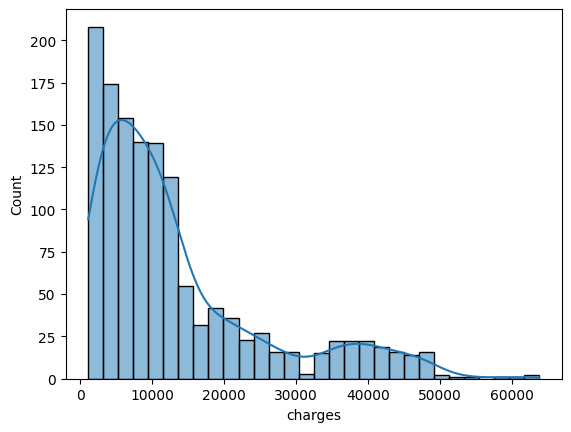

In [ ]:
#Vẽ phân phối target:

sns.histplot(pd_train['charges'], kde=True)
plt.show()

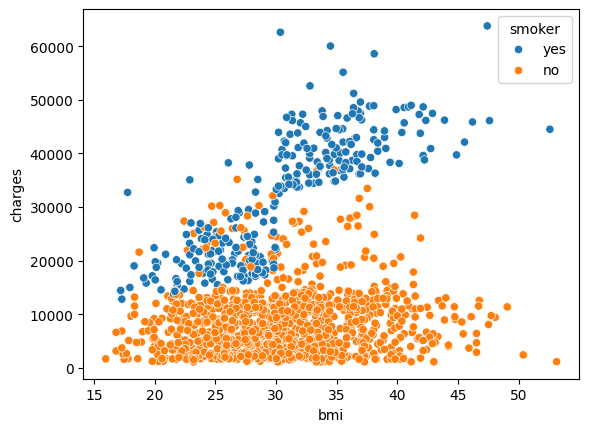

In [ ]:
#Kiểm tra quan hệ
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=pd_train)
plt.show()

In [4]:
#Encode biến phân loại:
pd_train = pd.get_dummies(pd_train, drop_first=True)
print("Dữ liệu sau khi mã hóa thành công:")
display(pd_train.head())

Dữ liệu sau khi mã hóa thành công:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


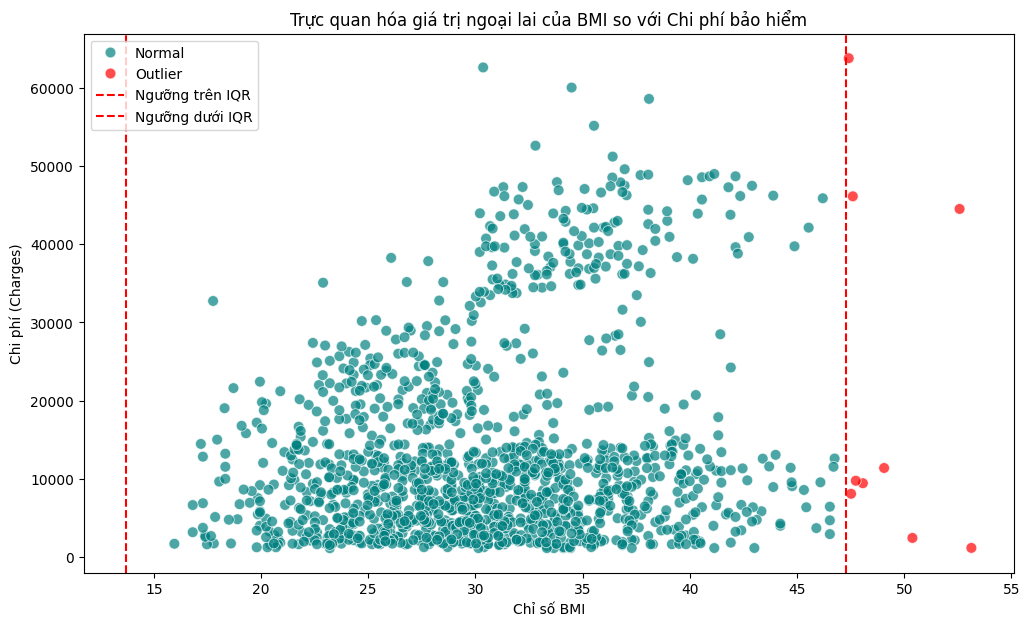

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tính toán ngưỡng IQR cho cột BMI
Q1 = pd_train['bmi'].quantile(0.25)
Q3 = pd_train['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Tạo cột phân loại Outlier
# Hàm này sẽ trả về 'Outlier' nếu giá trị nằm ngoài ngưỡng, ngược lại là 'Normal'
pd_train['is_outlier'] = pd_train['bmi'].apply(
    lambda x: 'Outlier' if (x < lower_bound or x > upper_bound) else 'Normal'
)

# 3. Vẽ biểu đồ phân tán (Scatter Plot)
plt.figure(figsize=(12, 7))

# Dùng tham số 'hue' để phân biệt màu sắc dựa trên cột 'is_outlier'
# 'palette' giúp bạn chọn màu cụ thể (ví dụ: đỏ cho Outlier, xanh cho Normal)
sns.scatterplot(
    data=pd_train,
    x='bmi',
    y='charges',
    hue='is_outlier',
    palette={'Normal': 'teal', 'Outlier': 'red'},
    alpha=0.7,
    s=60
)

# Vẽ thêm đường giới hạn để dễ quan sát
plt.axvline(x=upper_bound, color='red', linestyle='--', label='Ngưỡng trên IQR')
plt.axvline(x=lower_bound, color='red', linestyle='--', label='Ngưỡng dưới IQR')

plt.title('Trực quan hóa giá trị ngoại lai của BMI so với Chi phí bảo hiểm')
plt.xlabel('Chỉ số BMI')
plt.ylabel('Chi phí (Charges)')
plt.legend()
plt.show()

# Sau khi xem xong, bạn nhớ xóa cột tạm này để tránh ảnh hưởng bước huấn luyện
#pd_train.drop(columns=['is_outlier'], inplace=True)

In [7]:
pd_train.drop(columns=['is_outlier'], inplace=True)

In [8]:
#Xử lý các giá trị ngoại lai cho cột BMI
import numpy as np

# Giả sử đây là cột BMI trong dữ liệu của bạn
bmi_data = pd_train['bmi']

# 1. Tính Q1, Q3
Q1 = bmi_data.quantile(0.25)
Q3 = bmi_data.quantile(0.75)

# 2. Tính IQR
IQR = Q3 - Q1

# 3. Xác định ngưỡng
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# 4. Lọc dữ liệu
outliers = bmi_data[(bmi_data < lower_limit) | (bmi_data > upper_limit)]
df_cleaned = pd_train[(pd_train['bmi'] >= lower_limit) & (pd_train['bmi'] <= upper_limit)]

print(f"Ngưỡng an toàn của BMI: từ {lower_limit:.2f} đến {upper_limit:.2f}")
print(f"Số lượng Outliers bị loại bỏ: {len(outliers)}")

Ngưỡng an toàn của BMI: từ 13.70 đến 47.29
Số lượng Outliers bị loại bỏ: 9


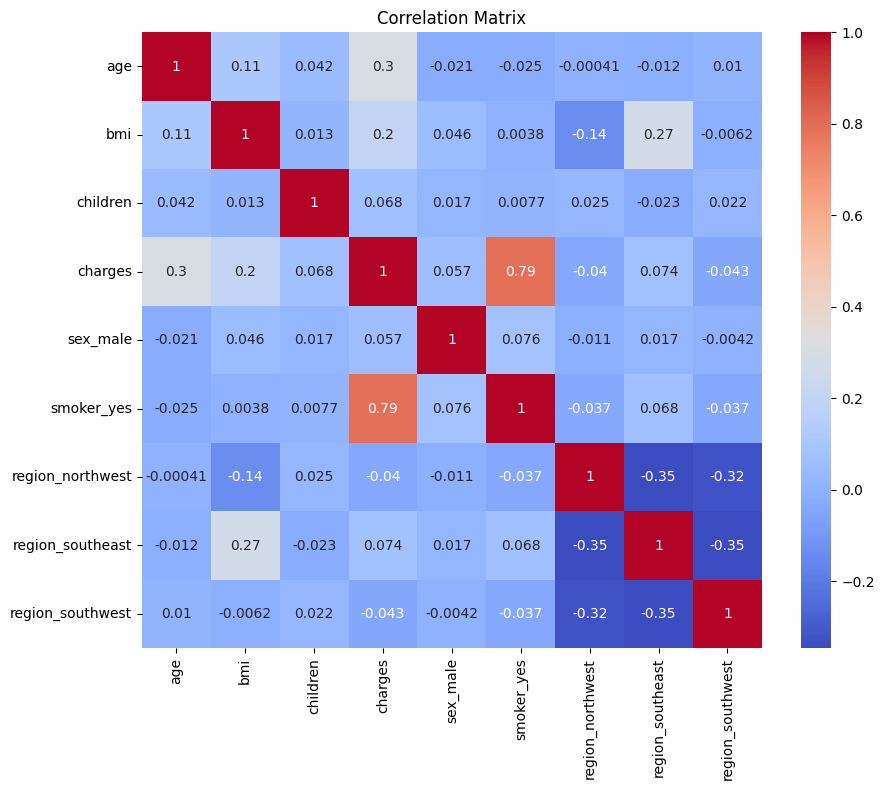

In [9]:
#Ma trận tương quan
import seaborn as sns
import matplotlib.pyplot as plt

corr = pd_train.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Baseline model
X = pd_train.drop('charges', axis=1)
y = pd_train['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Tính toán các chỉ số
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

R2 Score: 0.7836
MAE: 4181.1945
MSE: 33596915.8514
RMSE: 5796.2847


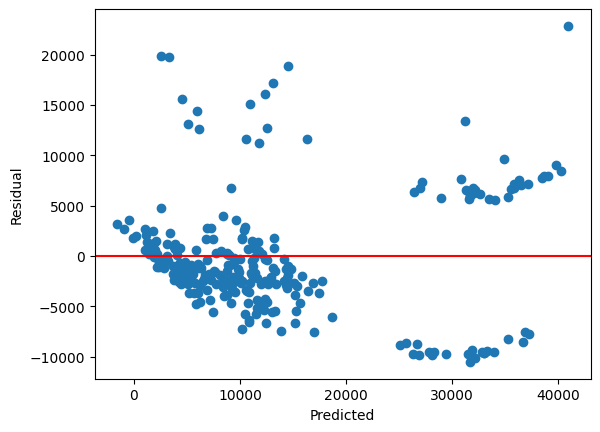

In [11]:
# Biểu đồ phần dư Residual plot
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.show()

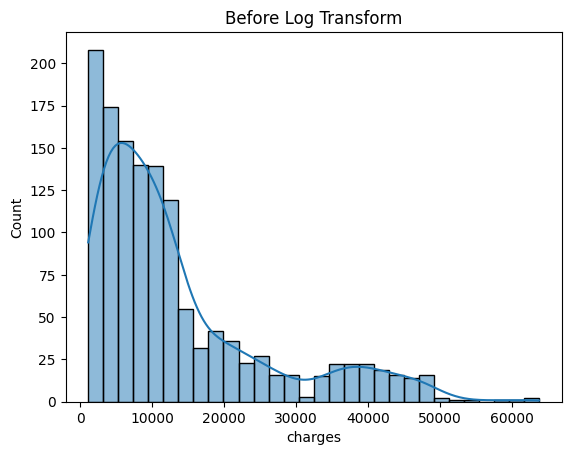

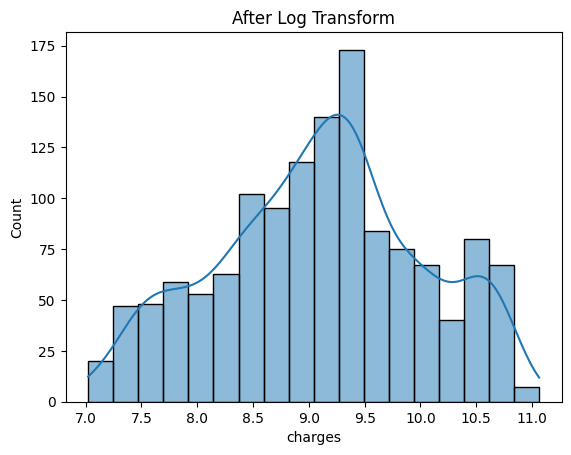

In [12]:
# Kiểm tra trước khi transform (nên làm)
sns.histplot(pd_train['charges'], kde=True)
plt.title("Before Log Transform")
plt.show()

# Log transform
pd_train['charges'] = np.log(pd_train['charges'])

# Kiểm tra lại
sns.histplot(pd_train['charges'], kde=True)
plt.title("After Log Transform")
plt.show()

In [13]:
# Tạo biến tương tác giữa BMI và smoker
#pd_train['bmi_smoker'] = pd_train['bmi'] * pd_train['smoker_yes']
pd_train['bmi_smoker'] = ((pd_train['bmi'] >= 30) & (pd_train['smoker_yes'] == 1)).astype(int)

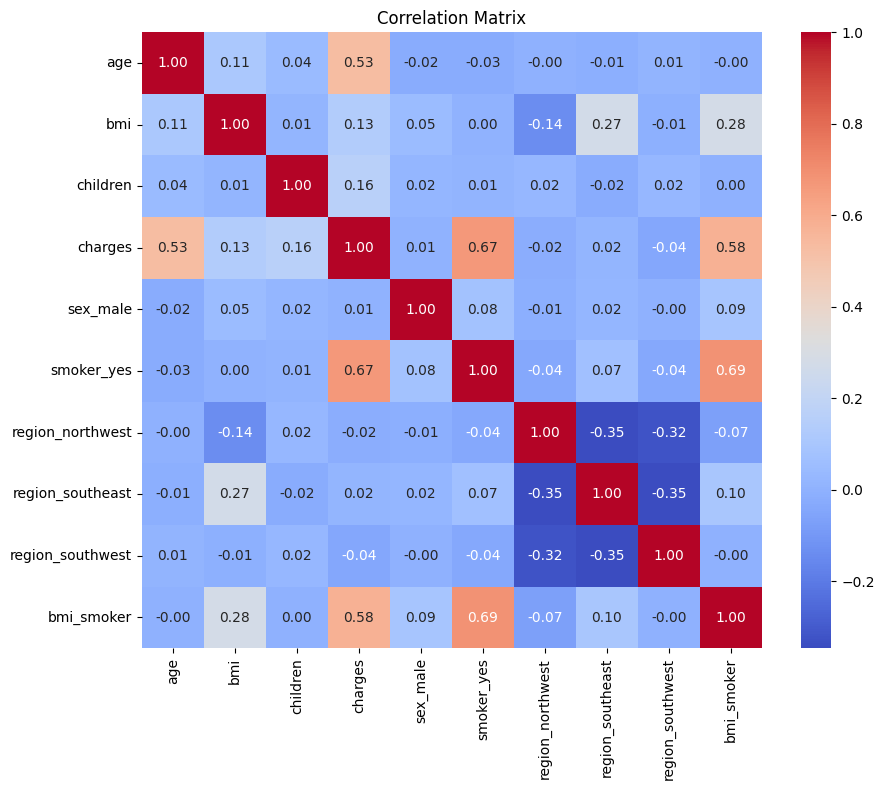

In [14]:
#Kiểm tra lại ma trận tương quan sau khi thêm biến
plt.figure(figsize=(10,8))
sns.heatmap(pd_train.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Epoch 0 | Train Loss: 31.0209 | Val Loss: 30.5095
Epoch 50 | Train Loss: 0.0925 | Val Loss: 0.0830
Epoch 100 | Train Loss: 0.0924 | Val Loss: 0.0826
Epoch 150 | Train Loss: 0.0924 | Val Loss: 0.0826


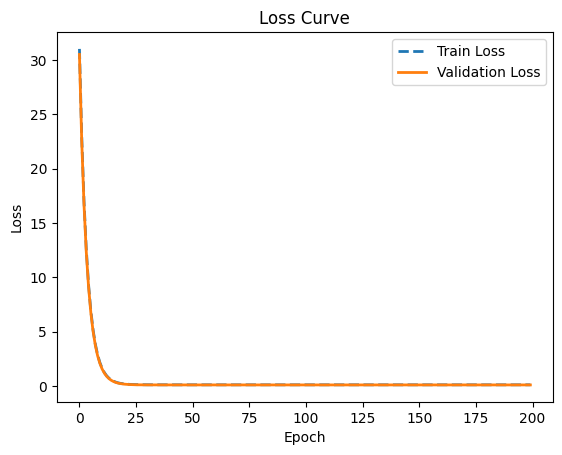


Evaluation:
MAE: 0.2399337190405769
MSE: 0.16468221362006052
RMSE: 0.40581056371176505
R2: 0.8030953750320589


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ======================
# 1. Chuẩn bị dữ liệu
# ======================
X = pd_train.drop('charges', axis=1).values
y = pd_train['charges'].values.reshape(-1, 1)

# ======================
# 2. Chia dữ liệu (TRƯỚC khi scale)
# ======================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ======================
# 3. Chuẩn hóa (FIT CHỈ TRÊN TRAIN)
# ======================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ======================
# 4. Thêm bias
# ======================
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_val = np.c_[np.ones(X_val.shape[0]), X_val]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

# ======================
# 5. Hyper-parameters
# ======================
learning_rate = 0.005
epochs = 200
batch_size = 32

# ======================
# 6. Loss function
# ======================
def compute_loss(X, y, w):
    m = len(y)
    return (1/(2*m)) * np.sum((X @ w - y)**2)

# ======================
# 7. Gradient Descent
# ======================
def gradient_descent(X_train, y_train, X_val, y_val, lr, epochs, batch_size):
    m, n = X_train.shape
    w = np.zeros((n, 1))

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]

        for i in range(0, m, batch_size):
            X_batch = X_train_shuffled[i:i+batch_size]
            y_batch = y_train_shuffled[i:i+batch_size]

            gradient = (1/len(y_batch)) * X_batch.T @ (X_batch @ w - y_batch)
            w = w - lr * gradient

        train_loss = compute_loss(X_train, y_train, w)
        val_loss = compute_loss(X_val, y_val, w)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if epoch % 50 == 0:
            print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return w, train_losses, val_losses

# ======================
# 8. Train model
# ======================
w, train_losses, val_losses = gradient_descent(
    X_train, y_train, X_val, y_val,
    lr=learning_rate,
    epochs=epochs,
    batch_size=batch_size
)

# ======================
# 9. Loss curve
# ======================
plt.plot(train_losses, linestyle='--', linewidth=2, label="Train Loss")
plt.plot(val_losses, linestyle='-', linewidth=2, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

# ======================
# 10. Evaluation
# ======================
y_pred = X_test @ w

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nEvaluation:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


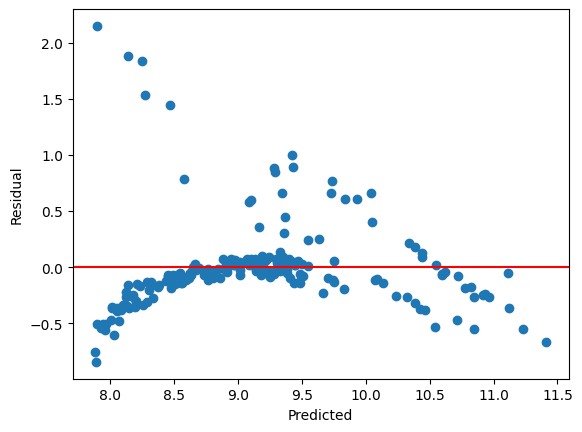

In [16]:
#Biểu đồ phần dư sau cải tiến
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.show()

In [17]:
#Tiếp tục cải tiến
# ======================
# 1. Feature Engineering (Nâng cấp biến số)
# ======================

# Thêm biến bậc 2 để xử lý tính phi tuyến (khử hình vòm trong Residual Plot)
pd_train['age2'] = pd_train['age'] ** 2
pd_train['bmi2'] = pd_train['bmi'] ** 2

# Thêm biến tương tác để xử lý nhóm rủi ro cao (Outliers)
# Nhóm béo phì (BMI >= 30) và có hút thuốc
pd_train['bmi_smoker'] = ((pd_train['bmi'] >= 30) & (pd_train['smoker_yes'] == 1)).astype(int)

# (Tùy chọn) Thêm tương tác giữa tuổi và hút thuốc để tăng độ chính xác
pd_train['age_smoker'] = pd_train['age'] * pd_train['smoker_yes']



Epoch 0 | Train Loss: 30.9763 | Val Loss: 30.4150
Epoch 50 | Train Loss: 0.0913 | Val Loss: 0.0835
Epoch 100 | Train Loss: 0.0817 | Val Loss: 0.0751
Epoch 150 | Train Loss: 0.0776 | Val Loss: 0.0716


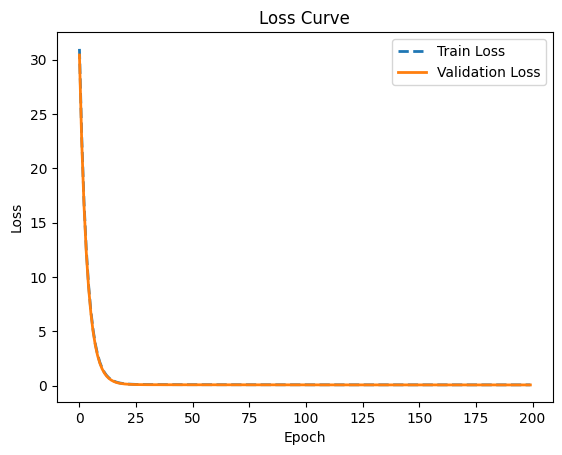


Evaluation:
MAE: 0.19066197329065823
MSE: 0.13897380569003867
RMSE: 0.37279190668526946
R2: 0.8338339976841846


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ======================
# 1. Chuẩn bị dữ liệu
# ======================
X = pd_train.drop('charges', axis=1).values
y = pd_train['charges'].values.reshape(-1, 1)

# ======================
# 2. Chia dữ liệu (TRƯỚC khi scale)
# ======================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ======================
# 3. Chuẩn hóa (FIT CHỈ TRÊN TRAIN)
# ======================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ======================
# 4. Thêm bias
# ======================
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_val = np.c_[np.ones(X_val.shape[0]), X_val]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

# ======================
# 5. Hyper-parameters
# ======================
learning_rate = 0.005
epochs = 200
batch_size = 32

# ======================
# 6. Loss function
# ======================
def compute_loss(X, y, w):
    m = len(y)
    return (1/(2*m)) * np.sum((X @ w - y)**2)

# ======================
# 7. Gradient Descent
# ======================
def gradient_descent(X_train, y_train, X_val, y_val, lr, epochs, batch_size):
    m, n = X_train.shape
    w = np.zeros((n, 1))

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]

        for i in range(0, m, batch_size):
            X_batch = X_train_shuffled[i:i+batch_size]
            y_batch = y_train_shuffled[i:i+batch_size]

            gradient = (1/len(y_batch)) * X_batch.T @ (X_batch @ w - y_batch)
            w = w - lr * gradient

        train_loss = compute_loss(X_train, y_train, w)
        val_loss = compute_loss(X_val, y_val, w)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if epoch % 50 == 0:
            print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return w, train_losses, val_losses

# ======================
# 8. Train model
# ======================
w, train_losses, val_losses = gradient_descent(
    X_train, y_train, X_val, y_val,
    lr=learning_rate,
    epochs=epochs,
    batch_size=batch_size
)

# ======================
# 9. Loss curve
# ======================
plt.plot(train_losses, linestyle='--', linewidth=2, label="Train Loss")
plt.plot(val_losses, linestyle='-', linewidth=2, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

# ======================
# 10. Evaluation
# ======================
y_pred = X_test @ w

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nEvaluation:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)
